In [15]:
# -- Carga de datos --
import numpy as np
import tensorflow as tf
tf.keras.backend.set_floatx('float64')
from tensorflow.keras.datasets import mnist

# Carga el dataset completo de MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Filtra las imágenes y etiquetas para incluir solo los dígitos 0 y 1
train_filter = np.where((y_train == 0) | (y_train == 1))
test_filter = np.where((y_test == 0) | (y_test == 1))

x_train_01, y_train_01 = x_train[train_filter], y_train[train_filter]
x_test_01, y_test_01 = x_test[test_filter], y_test[test_filter]

# --- 2. Submuestreo ---
# 100 de cada clase (0 y 1) para un total de 200.
indices_0 = np.where(y_train_01 == 0)[0][:100]
indices_1 = np.where(y_train_01 == 1)[0][:100]
indices_sample = np.concatenate([indices_0, indices_1])
np.random.shuffle(indices_sample) # Mezclar el subconjunto

x_train_sample = x_train_01[indices_sample]
y_train_sample = y_train_01[indices_sample]


# --- 3. Preprocesamiento (Normalización y Reshape) ---
# Normaliza los valores de píxel de [0, 255] a [0, 1]
x_train_sample = x_train_sample.astype('float64') / 255.0
x_test_01 = x_test_01.astype('float64') / 255.0

# ConvNN espera un canal de color (última dimensión). (200, 28, 28) -> (200, 28, 28, 1)
x_train_sample = np.expand_dims(x_train_sample, -1)
x_test_01 = np.expand_dims(x_test_01, -1)

print(f"Datos de entrenamiento muestreados: {x_train_sample.shape}, Etiquetas: {y_train_sample.shape}")

Datos de entrenamiento muestreados: (200, 28, 28, 1), Etiquetas: (200,)


In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense

# -- Modelo --
def c_model(input_shape):
    """
    Crea el modelo clásico (extractor de características ConvNN)
    con dos capas Conv2D y una capa Dense de salida unitaria (el parámetro theta).
    """
    model = Sequential([
        # Primera capa ConvNN 
        Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        # Segunda capa ConvNN 
        Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
        # Capa de aplanamiento para pasar a la capa densa
        Flatten(),
        # Capa totalmente conectada. SU ÚNICA SALIDA es el parámetro theta.
        Dense(units=1) 
    ])
    return model

# La forma de entrada debe ser (28, 28, 1)
input_shape = x_train_sample.shape[1:] 
clasic_model = c_model(input_shape)

print("Resumen del modelo clásico:")
clasic_model.summary()

Resumen del modelo clásico:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │        18,433 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,233 (181.51 KB)

 Trainable params: 23,233 (181.51 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Lambda

# --- Importaciones de Qiskit ---
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.primitives import Estimator
from qiskit_machine_learning.neural_networks import EstimatorQNN
import qiskit.quantum_info as qi
from tensorflow.keras.layers import Layer

# --- 1. Función para crear el circuito QAOA ---
def create_qaoa_circuit(num_qubits):
    theta = Parameter('theta')  
    gamma = Parameter('gamma')  
    beta = Parameter('beta')    
    
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits)) 
    
    # Capa de Costo (U_C)
    qc.cx(0, 1)
    qc.rz(gamma * theta, 1) 
    qc.cx(0, 1)
    
    # Capa de Mezclador (U_M)
    qc.rx(beta, 0)
    qc.rx(beta, 1)
    
    return qc, [theta], [gamma, beta]

# --- 2. Crear capa personalizada de Keras para QNN ---
class QiskitLayer(Layer):
    def __init__(self, qnn, **kwargs):
        super(QiskitLayer, self).__init__(**kwargs)
        self.qnn = qnn
        self.num_weights = len(qnn.weight_params)
        
    def build(self, input_shape):
        # Inicializar pesos cuánticos
        self.qnn_weights = self.add_weight(
            name='qnn_weights',
            shape=(self.num_weights,),
            initializer='random_uniform',
            trainable=True
        )
        super(QiskitLayer, self).build(input_shape)
    
    def _forward_and_backward(self, inputs_np, weights_np, upstream_np):
        """Calcula forward y backward en NumPy - asume que todos los inputs son arrays numpy"""
        # Asegurar que todo sea numpy
        if not isinstance(inputs_np, np.ndarray):
            inputs_np = np.array(inputs_np)
        if not isinstance(weights_np, np.ndarray):
            weights_np = np.array(weights_np)
        if not isinstance(upstream_np, np.ndarray):
            upstream_np = np.array(upstream_np)
            
        batch_size = inputs_np.shape[0]
        epsilon = 1e-4
        
        # Forward pass
        outputs = []
        for i in range(batch_size):
            input_val = inputs_np[i:i+1]
            result = self.qnn.forward(input_val, weights_np)
            outputs.append(result[0, 0])
        outputs = np.array(outputs, dtype=np.float64).reshape(-1, 1)
        
        # Backward pass - gradientes respecto a inputs
        input_grads = []
        for i in range(batch_size):
            input_val = inputs_np[i:i+1]
            
            # Diferencia finita central
            input_plus = input_val + epsilon
            out_plus = self.qnn.forward(input_plus, weights_np)[0, 0]
            
            input_minus = input_val - epsilon
            out_minus = self.qnn.forward(input_minus, weights_np)[0, 0]
            
            grad = (out_plus - out_minus) / (2 * epsilon)
            input_grads.append([grad])
        
        input_grads = np.array(input_grads, dtype=np.float64)
        
        # Backward pass - gradientes respecto a weights
        weight_grads = []
        for j in range(self.num_weights):
            weight_plus = weights_np.copy()
            weight_plus[j] += epsilon
            out_plus = self.qnn.forward(inputs_np[0:1], weight_plus)[0, 0]
            
            weight_minus = weights_np.copy()
            weight_minus[j] -= epsilon
            out_minus = self.qnn.forward(inputs_np[0:1], weight_minus)[0, 0]
            
            grad = (out_plus - out_minus) / (2 * epsilon)
            weight_grads.append(grad)
        
        weight_grads = np.array(weight_grads, dtype=np.float64)
        
        # Aplicar upstream gradient
        final_input_grad = input_grads * upstream_np
        final_weight_grad = weight_grads * np.sum(upstream_np)
        
        return outputs, final_input_grad, final_weight_grad
    
    @tf.custom_gradient
    def _qnn_call(self, inputs, weights):
        """Forward pass con gradientes"""
        # Forward usando py_function
        def forward_fn(inp, w):
            results = []
            for i in range(inp.shape[0]):
                result = self.qnn.forward(inp[i:i+1], w)
                results.append(result[0, 0])
            return np.array(results, dtype=np.float64).reshape(-1, 1)
        
        output = tf.py_function(
            func=forward_fn,
            inp=[inputs, weights],
            Tout=tf.float64
        )
        output.set_shape([inputs.shape[0], 1])
        
        def grad_fn(upstream):
            """Calcula gradientes usando diferencias finitas"""
            def backward_fn(inp, w, ups):
                # Convertir explícitamente a numpy dentro de py_function
                inp_np = np.array(inp, dtype=np.float64)
                w_np = np.array(w, dtype=np.float64)
                ups_np = np.array(ups, dtype=np.float64)
                
                _, input_grad, weight_grad = self._forward_and_backward(inp_np, w_np, ups_np)
                return input_grad, weight_grad
            
            input_grad, weight_grad = tf.py_function(
                func=backward_fn,
                inp=[inputs, weights, upstream],
                Tout=[tf.float64, tf.float64]
            )
            
            input_grad.set_shape([inputs.shape[0], 1])
            weight_grad.set_shape([self.num_weights])
            
            return input_grad, weight_grad
        
        return output, grad_fn
    
    def call(self, inputs):
        # Reshape para asegurar dimensiones correctas
        inputs_reshaped = tf.reshape(inputs, [-1, 1])
        
        # Ejecutar forward pass con gradientes personalizados
        output = self._qnn_call(inputs_reshaped, self.qnn_weights)
        
        return output

# 3. Creamos el EstimatorQNN
qc, input_params, weight_params = create_qaoa_circuit(num_qubits=2)
observable = qi.SparsePauliOp("ZI") 

qnn = EstimatorQNN(
    circuit=qc,
    observables=[observable],
    input_params=input_params,
    weight_params=weight_params,
    estimator=Estimator() 
)

# 4. Crear la capa cuántica personalizada
qiskit_layer = QiskitLayer(qnn) 

print("✅ Circuito QAOA de Qiskit definido con capa personalizada y gradientes.")

✅ Circuito QAOA de Qiskit definido con capa personalizada y gradientes.


C:\Users\laura\AppData\Local\Temp\ipykernel_29600\1997286178.py:170: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  estimator=Estimator()
C:\Users\laura\AppData\Local\Temp\ipykernel_29600\1997286178.py:165: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


In [18]:
# ASUMIMOS que input_shape = (28, 28, 1)
input_shape = (28, 28, 1) 

# --- Definición de la Entrada y Extractor Clásico (API Funcional) ---
input_tensor = Input(shape=input_shape) 
x = Conv2D(filters=16, kernel_size=(3, 3), activation='relu')(input_tensor)
x = Conv2D(filters=32, kernel_size=(3, 3), activation='relu')(x)
x = Flatten()(x)

# Salida clásica: el parámetro theta (dim=1)
theta_output = Dense(units=1)(x) 

# --- Capa Cuántica ---
# La salida de la ConvNN (theta) es la entrada para el QNN de Qiskit
quantum_output = qiskit_layer(theta_output)

# --- Capa de Mapeo Final ---
# 🚨 Paso CRUCIAL: Mapeamos [-1, 1] a [0, 1] con (x + 1) / 2
# Usamos una capa Lambda para implementar esta función
final_output = Lambda(lambda x: (x + 1.0) / 2.0)(quantum_output)


# --- Creación y Compilación del Modelo Híbrido ---
hybrid_model = Model(inputs=input_tensor, outputs=final_output, name="VQNN_Qiskit_Hybrid")

hybrid_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss=tf.keras.losses.BinaryCrossentropy(), # Ahora compatible con la salida [0, 1]
    metrics=['accuracy']
)

print("✅ Modelo Híbrido VQNN Qiskit ensamblado con mapeo de salida.")
hybrid_model.summary()

✅ Modelo Híbrido VQNN Qiskit ensamblado con mapeo de salida.



Model: "VQNN_Qiskit_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │        18,433 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qiskit_layer_3 (QiskitLayer)    │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,235 (181.52 KB)

 Trainable params: 23,235 (181.52 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Hiperparámetros de entrenamiento
EPOCHS = 20 
BATCH_SIZE = 4 

print("Iniciando entrenamiento del modelo VQNN híbrido Qiskit...")

history = hybrid_model.fit(
    x_train_sample, 
    y_train_sample, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    validation_split=0.1, 
    verbose=1
)

Iniciando entrenamiento del modelo VQNN híbrido Qiskit...
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.5111 - loss: 0.6931 - val_accuracy: 0.4000 - val_loss: 0.6931
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/s

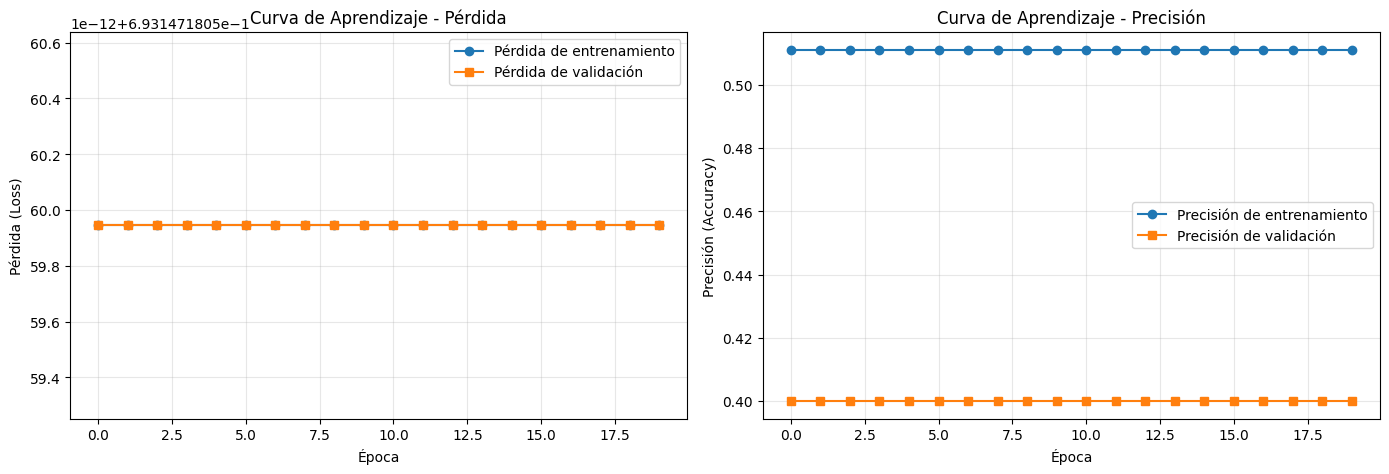


📊 Métricas finales:
  • Pérdida de entrenamiento: 0.6931
  • Pérdida de validación: 0.6931
  • Precisión de entrenamiento: 0.5111
  • Precisión de validación: 0.4000


In [20]:
import matplotlib.pyplot as plt

# --- Visualización de la Curva de Aprendizaje ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de pérdida (loss)
axes[0].plot(history.history['loss'], label='Pérdida de entrenamiento', marker='o')
axes[0].plot(history.history['val_loss'], label='Pérdida de validación', marker='s')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (Loss)')
axes[0].set_title('Curva de Aprendizaje - Pérdida')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica de precisión (accuracy)
axes[1].plot(history.history['accuracy'], label='Precisión de entrenamiento', marker='o')
axes[1].plot(history.history['val_accuracy'], label='Precisión de validación', marker='s')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión (Accuracy)')
axes[1].set_title('Curva de Aprendizaje - Precisión')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Métricas finales:")
print(f"  • Pérdida de entrenamiento: {history.history['loss'][-1]:.4f}")
print(f"  • Pérdida de validación: {history.history['val_loss'][-1]:.4f}")
print(f"  • Precisión de entrenamiento: {history.history['accuracy'][-1]:.4f}")
print(f"  • Precisión de validación: {history.history['val_accuracy'][-1]:.4f}")